# Problem Statement: Analyze Demographics and Socio-Economic Indicators for Indigenous Tribes in India
**Project ID:** CEP-71  
**Roll No:** 1601-25-737-022  
**Name of the Student:** Govindu Tejasri  
**Department:** Information Technology (INF)  
**Institution:** Chaitanya Bharathi Institute of Technology, Hyderabad

## Problem Overview

The indigenous tribal communities of India exhibit significant variations in population, regional distribution, literacy rate, sex ratio, and other socio-economic characteristics. These variations can be difficult to understand from raw demographic data alone. This project applies Exploratory Data Analysis (EDA) techniques to analyze demographic and socio-economic indicators of indigenous tribes in India, identify regional and tribal-level patterns, handle missing data, and present meaningful insights through statistical analysis and visualizations.

DATASET LINK:https://1drv.ms/x/c/9D0979E2CA58C8A6/IQArieH1EvQPTp6EdzAitAmmAY87cyqa0hfcy8oSIW59i-s?e=J8dPql

## Environment

- **Programming Language:** Python 3.x
- **Platform:** Jupyter Notebook
- **Libraries Used:**
  - **NumPy** – Numerical and statistical calculations
  - **Pandas** – Data loading, cleaning, filtering, and grouping
  - **Matplotlib** – Data visualization and plotting
  - **Seaborn** – Statistical data visualization

In [195]:
print("EDAV Project")

EDAV Project


## 1. Data Loading and Understanding

The dataset is based on the Census of India 2011 Primary Census Abstract for Individual Scheduled Tribes (A-11). It contains demographic and socio-economic information for Scheduled Tribes across selected Indian states. The raw Excel file contains multi-level headers, residence categories, and several demographic and workforce indicators. Before performing analysis, the dataset is explored and cleaned to obtain a reliable analytical dataset.

In [196]:
# Importing required  libraries in python
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [197]:
# Checking the files in the current folder
import os
print(os.listdir())

['.ipynb_checkpoints', '1601-25-737-022_CEP-71_Analyze_Demographics_and_Socio_Economic_Indicators_for_Indigenous_Tribes_in_India.ipynb.ipynb', 'copy dataset.xlsx']


In [198]:
# Reading the Excel file
df = pd.read_excel("copy dataset.xlsx")
# Checking the first few rows
df.head()

,A-11 STATE PRIMARY CENSUS ABSTRACT FOR INDIVIDUAL SCHEDULED TRIBES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Table Name,State Code,District Code,Area Name,ST Code,ST Name,T/R/U,Number of households with at least one st member,Total Population(including institutional and h...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non Workers,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,M,...,F,P,M,F,P,M,F,P,M,F
3,1,2,3,4,5,6,7,8,9,10,...,77,78,79,80,81,82,83,84,85,86
4,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Total,1495485,5918073,2969362,...,38334,3978,1478,2500,15470,7498,7972,2710022,1302682,1407340


In [199]:
# Checking the column names in the dataset
print(df.columns)

Index(['A-11 STATE PRIMARY CENSUS ABSTRACT FOR INDIVIDUAL SCHEDULED TRIBES',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30',
       'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34',
       'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38',
       'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42',
       'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46',
       'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50',
       'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54',
       'Unnamed: 55', 'Unnamed:

In [200]:
# Checking the shape of the dataset
df.shape

(891, 86)

In [201]:
# iloc[] selects rows by their position; here we remove the first 4 rows
data = df.iloc[4:].copy()
# head() displays the first 5 rows to check the result
data.head()

,A-11 STATE PRIMARY CENSUS ABSTRACT FOR INDIVIDUAL SCHEDULED TRIBES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85
4,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Total,1495485,5918073,2969362,...,38334,3978,1478,2500,15470,7498,7972,2710022,1302682,1407340
5,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Rural,1316055,5232129,2620892,...,37385,3488,1278,2210,11719,5533,6186,2290210,1127840,1162370
6,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Urban,179430,685944,348470,...,949,490,200,290,3751,1965,1786,419812,174842,244970
7,A10ST1,28,00,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Total,3193,13197,6604,...,21,7,4,3,24,15,9,6194,2990,3204
8,A10ST1,28,00,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Rural,2929,12343,6186,...,18,7,4,3,19,10,9,5646,2773,2873


In [202]:
# iloc[:, 0] selects the first column of all rows
# == "A10ST1" keeps only rows whose first column contains the Census code A10ST1
# copy() creates a separate DataFrame for the filtered data
data = data[data.iloc[:, 0] == "A10ST1"].copy()
# head() displays the first 5 rows to check the filtered data
data.head()

,A-11 STATE PRIMARY CENSUS ABSTRACT FOR INDIVIDUAL SCHEDULED TRIBES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85
4,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Total,1495485,5918073,2969362,...,38334,3978,1478,2500,15470,7498,7972,2710022,1302682,1407340
5,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Rural,1316055,5232129,2620892,...,37385,3488,1278,2210,11719,5533,6186,2290210,1127840,1162370
6,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Urban,179430,685944,348470,...,949,490,200,290,3751,1965,1786,419812,174842,244970
7,A10ST1,28,00,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Total,3193,13197,6604,...,21,7,4,3,24,15,9,6194,2990,3204
8,A10ST1,28,00,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Rural,2929,12343,6186,...,18,7,4,3,19,10,9,5646,2773,2873


In [203]:
# iloc[4:] selects all rows starting from row position 4
# copy() creates a separate DataFrame for further cleaning
data = df.iloc[4:].copy()
# iloc[:, 0] selects the first column
# == "A10ST1" keeps only rows containing the required Census code
# copy() creates a separate copy of the filtered rows
data = data[data.iloc[:, 0] == "A10ST1"].copy()
# reset_index() creates a new index from 0
# drop=True removes the old index instead of keeping it as a new column
data = data.reset_index(drop=True)
# head() displays the first 5 rows to check the cleaned data
data.head()

,A-11 STATE PRIMARY CENSUS ABSTRACT FOR INDIVIDUAL SCHEDULED TRIBES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,Unnamed: 85
0,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Total,1495485,5918073,2969362,...,38334,3978,1478,2500,15470,7498,7972,2710022,1302682,1407340
1,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Rural,1316055,5232129,2620892,...,37385,3488,1278,2210,11719,5533,6186,2290210,1127840,1162370
2,A10ST1,28,00,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Urban,179430,685944,348470,...,949,490,200,290,3751,1965,1786,419812,174842,244970
3,A10ST1,28,00,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Total,3193,13197,6604,...,21,7,4,3,24,15,9,6194,2990,3204
4,A10ST1,28,00,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Rural,2929,12343,6186,...,18,7,4,3,19,10,9,5646,2773,2873


In [204]:
# Select only the columns needed for the project
# iloc[] selects rows and columns using their integer positions
# : selects all rows, and the numbers specify the required column positions
clean_df = data.iloc[:, [
    1, 3, 4, 5, 6, 8, 9, 10, 11, 14, 20, 23
]].copy()
# Rename the selected columns with meaningful names
# columns is used to access and change the column names
clean_df.columns = [
    "State_Code",
    "Area_Name",
    "ST_Code",
    "Tribe",
    "Residence",
    "Population",
    "Male_Population",
    "Female_Population",
    "Age_0_6",
    "Literate",
    "Total_Workers",
    "Main_Workers"
]
# head() displays the first 5 rows to check the selected and renamed columns
clean_df.head()

,State_Code,Area_Name,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers
0,28,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Total,5918073,2969362,2948711,770975,2532727,3208051,2565865
1,28,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Rural,5232129,2620892,2611237,686511,2130838,2941919,2343564
2,28,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Urban,685944,348470,337474,84464,401889,266132,222301
3,28,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Total,13197,6604,6593,2041,6071,7003,6111
4,28,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Rural,12343,6186,6157,1959,5527,6697,5874


In [205]:
# isnull() checks for missing values and sum() counts them in each column
missing = clean_df.isnull().sum()
print(missing)
# to_numeric() converts State_Code into a numeric data type
# errors="coerce" changes invalid values into NaN instead of showing an error
clean_df["State_Code"] = pd.to_numeric(
    clean_df["State_Code"],
    errors="coerce"
)

State_Code           0
Area_Name            1
ST_Code              0
Tribe                0
Residence            0
Population           0
Male_Population      0
Female_Population    0
Age_0_6              0
Literate             0
Total_Workers        0
Main_Workers         0
dtype: int64


In [206]:
# isnull() identifies missing values in the Area_Name column
# [] filters the DataFrame to keep only rows where Area_Name is missing
clean_df[clean_df["Area_Name"].isnull()]

,State_Code,Area_Name,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers
760,23,NaN,502,Andh,Rural,37,18,19,8,18,15,14


In [207]:
# Create a dictionary to map each State_Code to its state name
state_mapping = {
    18: "Assam",
    20: "Jharkhand",
    21: "Odisha",
    22: "Chhattisgarh",
    23: "Madhya Pradesh",
    27: "Maharashtra",
    28: "Andhra Pradesh"
}
# map() replaces each State_Code with its corresponding state name
clean_df["State"] = clean_df["State_Code"].map(state_mapping)

In [208]:
# isnull() identifies missing values in the Area_Name column
# [] filters the DataFrame to display only rows where Area_Name is missing
clean_df[clean_df["Area_Name"].isnull()]

,State_Code,Area_Name,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State
760,23,NaN,502,Andh,Rural,37,18,19,8,18,15,14,Madhya Pradesh


In [209]:
# copy() creates an independent copy of the DataFrame
# This keeps the original clean_df unchanged while we work on copy_df
copy_df = clean_df.copy()
# head() displays the first 5 rows to check the copied data
copy_df.head()

,State_Code,Area_Name,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State
0,28,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Total,5918073,2969362,2948711,770975,2532727,3208051,2565865,Andhra Pradesh
1,28,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Rural,5232129,2620892,2611237,686511,2130838,2941919,2343564,Andhra Pradesh
2,28,STATE - ANDHRA PRADESH 28,500,All Schedule Tribes,Urban,685944,348470,337474,84464,401889,266132,222301,Andhra Pradesh
3,28,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Total,13197,6604,6593,2041,6071,7003,6111,Andhra Pradesh
4,28,STATE - ANDHRA PRADESH 28,501,"Andh, Sadhu Andh",Rural,12343,6186,6157,1959,5527,6697,5874,Andhra Pradesh


In [210]:
# drop() removes the Area_Name column from clean_df
# columns= specifies that a column, rather than rows, should be removed
clean_df = clean_df.drop(columns=["Area_Name"])

In [211]:
# head() displays the first 5 rows of clean_df
# It is used to check the DataFrame after removing Area_Name
clean_df.head()

,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State
0,28,500,All Schedule Tribes,Total,5918073,2969362,2948711,770975,2532727,3208051,2565865,Andhra Pradesh
1,28,500,All Schedule Tribes,Rural,5232129,2620892,2611237,686511,2130838,2941919,2343564,Andhra Pradesh
2,28,500,All Schedule Tribes,Urban,685944,348470,337474,84464,401889,266132,222301,Andhra Pradesh
3,28,501,"Andh, Sadhu Andh",Total,13197,6604,6593,2041,6071,7003,6111,Andhra Pradesh
4,28,501,"Andh, Sadhu Andh",Rural,12343,6186,6157,1959,5527,6697,5874,Andhra Pradesh


In [212]:
# duplicated() identifies rows that are exact duplicates
# sum() counts the number of duplicate rows
duplicate_count = clean_df.duplicated().sum()
# Display the duplicate rows, if any
clean_df[clean_df.duplicated()]

,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State


In [213]:
# print() displays the number of duplicate rows found
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [214]:
# value_counts() counts how many times each unique value appears in the Residence column
clean_df["Residence"].value_counts()

Residence
Total    295
Rural    295
Urban    295
Name: count, dtype: int64

In [215]:
# [] filters the DataFrame to keep only rows where Residence is "Total"
# copy() creates an independent DataFrame for the analysis
analysis_df = clean_df[
    clean_df["Residence"] == "Total"].copy()
# reset_index() creates a new index starting from 0
# drop=True removes the old index instead of storing it as a new column
analysis_df = analysis_df.reset_index(drop=True)

In [216]:
# shape returns the number of rows and columns in the DataFrame
analysis_df.shape

(295, 12)

In [217]:
# info() displays the structure, data types, and non-null values of the DataFrame
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   State_Code         295 non-null    int64 
 1   ST_Code            295 non-null    object
 2   Tribe              295 non-null    object
 3   Residence          295 non-null    object
 4   Population         295 non-null    object
 5   Male_Population    295 non-null    object
 6   Female_Population  295 non-null    object
 7   Age_0_6            295 non-null    object
 8   Literate           295 non-null    object
 9   Total_Workers      295 non-null    object
 10  Main_Workers       295 non-null    object
 11  State              295 non-null    str   
dtypes: int64(1), object(10), str(1)
memory usage: 30.7+ KB


In [218]:
# Store the columns that should contain numeric values
numeric_columns = [
    "State_Code",
    "ST_Code",
    "Population",
    "Male_Population",
    "Female_Population",
    "Age_0_6",
    "Literate",
    "Total_Workers",
    "Main_Workers"
]
# Convert each selected column into numeric data
# to_numeric() converts valid values to numbers
# errors="coerce" converts invalid values into NaN
for column in numeric_columns:analysis_df[column] = pd.to_numeric(analysis_df[column],errors="coerce")

In [219]:
# info() displays the structure, data types, and non-null values of the DataFrame
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   State_Code         295 non-null    int64 
 1   ST_Code            295 non-null    int64 
 2   Tribe              295 non-null    object
 3   Residence          295 non-null    object
 4   Population         295 non-null    int64 
 5   Male_Population    295 non-null    int64 
 6   Female_Population  295 non-null    int64 
 7   Age_0_6            295 non-null    int64 
 8   Literate           295 non-null    int64 
 9   Total_Workers      295 non-null    int64 
 10  Main_Workers       295 non-null    int64 
 11  State              295 non-null    str   
dtypes: int64(9), object(2), str(1)
memory usage: 30.7+ KB


In [220]:
# Create a dictionary to map each state to its corresponding region
region_mapping = {
    "Madhya Pradesh": "Central",
    "Chhattisgarh": "Central",
    "Odisha": "East",
    "Jharkhand": "East",
    "Maharashtra": "West",
    "Assam": "Northeast",
    "Andhra Pradesh": "South"
}
# map() replaces each state name with its corresponding region
analysis_df["Region"] = analysis_df["State"].map(region_mapping)

In [221]:
# head() displays the first 5 rows of analysis_df
# It is used to check whether the Region column was added correctly
analysis_df.head()

,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region
0,28,500,All Schedule Tribes,Total,5918073,2969362,2948711,770975,2532727,3208051,2565865,Andhra Pradesh,South
1,28,501,"Andh, Sadhu Andh",Total,13197,6604,6593,2041,6071,7003,6111,Andhra Pradesh,South
2,28,502,Bagata,Total,133427,65333,68094,15247,60478,76907,54010,Andhra Pradesh,South
3,28,503,Bhil,Total,604,297,307,83,297,283,268,Andhra Pradesh,South
4,28,504,Chenchu,Total,64227,32196,32031,11302,21509,34405,27318,Andhra Pradesh,South


In [222]:
# Calculate the population aged 7 years and above
population_7_above = (
    analysis_df["Population"] - analysis_df["Age_0_6"])
# Calculate Literacy Rate as a percentage
analysis_df["Literacy_Rate"] = (
    analysis_df["Literate"] / population_7_above) * 100
# round() keeps the Literacy Rate to 2 decimal places
analysis_df["Literacy_Rate"] = analysis_df["Literacy_Rate"].round(2)
# head() displays the first 5 rows to check the new column
analysis_df.head()

,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate
0,28,500,All Schedule Tribes,Total,5918073,2969362,2948711,770975,2532727,3208051,2565865,Andhra Pradesh,South,49.21
1,28,501,"Andh, Sadhu Andh",Total,13197,6604,6593,2041,6071,7003,6111,Andhra Pradesh,South,54.42
2,28,502,Bagata,Total,133427,65333,68094,15247,60478,76907,54010,Andhra Pradesh,South,51.17
3,28,503,Bhil,Total,604,297,307,83,297,283,268,Andhra Pradesh,South,57.01
4,28,504,Chenchu,Total,64227,32196,32031,11302,21509,34405,27318,Andhra Pradesh,South,40.64


In [223]:
# Check how many Literacy Rate values are greater than 100%
# sum() counts the True values produced by the condition
(analysis_df["Literacy_Rate"] > 100).sum()

np.int64(0)

In [224]:
# Check how many records have a male population of 0
# sum() counts the True values produced by the condition
(analysis_df["Male_Population"] == 0).sum()

np.int64(0)

In [225]:
# Calculate Sex Ratio as the number of females per 1000 males
analysis_df["Sex_Ratio"] = (
    analysis_df["Female_Population"] /analysis_df["Male_Population"]) * 1000
# round() keeps the Sex Ratio to 2 decimal places
analysis_df["Sex_Ratio"] = analysis_df["Sex_Ratio"].round(2)
# tail() displays the last 5 rows to check the calculated column
analysis_df.tail()

,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
290,23,539,"Sahariya, Saharia, Seharia, Sehria, Sosia, Sor",Total,614958,316541,298417,139447,200243,276009,176812,Madhya Pradesh,Central,42.11,942.74
291,23,540,"Saonta, Saunta",Total,190,113,77,25,69,113,72,Madhya Pradesh,Central,41.82,681.42
292,23,541,Saur,Total,167340,86357,80983,34923,59877,78440,51275,Madhya Pradesh,Central,45.22,937.77
293,23,542,"Sawar, Sawara",Total,881,464,417,179,396,387,191,Madhya Pradesh,Central,56.41,898.71
294,23,543,Sonr,Total,12905,6644,6261,2798,4629,6004,3914,Madhya Pradesh,Central,45.80,942.35


In [226]:
# drop_duplicates() removes repeated State-Region combinations
# It helps verify that each state is mapped to the expected region
analysis_df[["State", "Region"]].drop_duplicates()

,State,Region
0,Andhra Pradesh,South
36,Assam,Northeast
66,Maharashtra,West
112,Jharkhand,East
145,Odisha,East
208,Chhattisgarh,Central
251,Madhya Pradesh,Central


In [227]:
# duplicated() checks for exact duplicate rows
# sum() counts the number of duplicate rows found
duplicate_count = analysis_df.duplicated().sum()
# print() displays the duplicate count
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [228]:
# isna() checks for missing values in the Region column
# sum() counts the missing values
analysis_df["Region"].isna().sum()

np.int64(0)

In [229]:
# info() displays the structure, data types, and non-null values of analysis_df
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State_Code         295 non-null    int64  
 1   ST_Code            295 non-null    int64  
 2   Tribe              295 non-null    object 
 3   Residence          295 non-null    object 
 4   Population         295 non-null    int64  
 5   Male_Population    295 non-null    int64  
 6   Female_Population  295 non-null    int64  
 7   Age_0_6            295 non-null    int64  
 8   Literate           295 non-null    int64  
 9   Total_Workers      295 non-null    int64  
 10  Main_Workers       295 non-null    int64  
 11  State              295 non-null    str    
 12  Region             295 non-null    str    
 13  Literacy_Rate      295 non-null    float64
 14  Sex_Ratio          295 non-null    float64
dtypes: float64(2), int64(9), object(2), str(2)
memory usage: 39.3+ KB


In [230]:
# Check whether Population equals Male_Population + Female_Population
population_check = (
    analysis_df["Population"]
    == analysis_df["Male_Population"] + analysis_df["Female_Population"])
# ~ changes True to False and False to True
# sum() counts the records where the population calculation is incorrect
print("Incorrect population records:", (~population_check).sum())

Incorrect population records: 0


In [231]:
# Check whether the population aged 0-6 is not greater than the total Population
age_check = (analysis_df["Age_0_6"] <= analysis_df["Population"])
# ~ reverses the Boolean result and sum() counts the invalid records
print("Invalid age-group records:", (~age_check).sum())

Invalid age-group records: 0


In [232]:
# Check whether the literate population is not greater than the population aged 7 and above
literacy_check = (analysis_df["Literate"] <= population_7_above)
# ~ reverses the Boolean result and sum() counts the invalid records
print("Invalid literacy records:", (~literacy_check).sum())

Invalid literacy records: 0


## Q1:Calculate population statistics with numpy (Bloom's Level:3)

In [233]:
# to_numpy() converts the Population column from a Pandas Series to a NumPy array
population_array = analysis_df["Population"].to_numpy()
# np.shape() returns the dimensions of the NumPy array
print(np.shape(population_array))
# NumPy functions are used to calculate the population statistics
total = np.sum(population_array)          # Calculates total population
mean = np.mean(population_array)           # Calculates average population
minimum = np.min(population_array)         # Finds minimum population
maximum = np.max(population_array)         # Finds maximum population
standard = np.std(population_array)        # Calculates standard deviation
# print() displays the calculated results
print("Total Population:", total)
print("Mean Population:", round(mean, 2))
print("Min Population:", minimum)
print("Max Population:", maximum)
print("Standard Deviation:", round(standard, 2))

(295,)
Total Population: 122190628
Mean Population: 414205.52
Min Population: 3
Max Population: 15316784
Standard Deviation: 1540307.21


## Q2: Filter Tribes by Region Using Pandas Bloom's Level: 3

In [234]:
# value_counts() counts how many records belong to each Region
analysis_df["Region"].value_counts()

Region
East         96
Central      87
West         46
South        36
Northeast    30
Name: count, dtype: int64

In [235]:
# groupby() divides the data into separate groups based on Region
region_groups = analysis_df.groupby("Region")
# Loop through each regional group
for region, group in region_groups:
    # sort_values() arranges each group using the required priority order
    # State is alphabetical, while Population, Literacy_Rate and Sex_Ratio are descending
    group = group.sort_values(
        by=["State", "Population", "Literacy_Rate", "Sex_Ratio"],
        ascending=[True, False, False, False] )
    # print() displays the name of the current region
    print("\n---", region, "---")
    # display() shows the complete regional DataFrame as a table
    display(group)


--- Central ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
208,22,500,All Schedule Tribes,Total,7822902,3873191,3949711,1199092,3913827,4131903,2490127,Chhattisgarh,Central,59.09,1019.76
224,22,516,"Gond, Arakh, Arrakh, Agaria, Asur, Badi Maria...",Total,4298404,2120974,2177430,663050,2060763,2281449,1398472,Chhattisgarh,Central,56.69,1026.62
228,22,520,"Kawar, Kanwar, Kaur, Cherwa, Rathia, Tanwar...",Total,887477,441242,446235,129330,508183,463254,278482,Chhattisgarh,Central,67.03,1011.32
241,22,533,"Oraon, Dhanka, Dhangad",Total,748789,373065,375724,104585,444061,395495,237030,Chhattisgarh,Central,68.93,1007.13
225,22,517,"Halba,Halbi",Total,375182,183877,191305,46435,250434,198615,139936,Chhattisgarh,Central,76.18,1040.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,23,540,"Saonta, Saunta",Total,190,113,77,25,69,113,72,Madhya Pradesh,Central,41.82,681.42
253,23,502,Andh,Total,137,70,67,26,90,54,49,Madhya Pradesh,Central,81.08,957.14
289,23,538,Parja,Total,137,70,67,27,55,66,41,Madhya Pradesh,Central,50.00,957.14
274,23,523,"Kondh, Khond, Kandh",Total,109,54,55,25,61,45,35,Madhya Pradesh,Central,72.62,1018.52



--- East ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
112,20,500,All Schedule Tribes,Total,8645042,4315407,4329635,1466933,4101010,4058020,1874577,Jharkhand,East,57.13,1003.30
139,20,527,Santal,Total,2754723,1371168,1383555,461459,1165823,1324771,524628,Jharkhand,East,50.84,1009.03
137,20,525,"Oraon, Dhangar (Oraon)",Total,1716618,855210,861408,270861,968132,779699,415263,Jharkhand,East,66.96,1007.25
136,20,524,"Munda, Patar",Total,1229221,614199,615022,198980,644976,589735,313817,Jharkhand,East,62.60,1001.34
125,20,513,Ho,Total,928289,459209,469080,176764,405842,425883,200838,Jharkhand,East,54.00,1021.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,21,516,Desua Bhumij,Total,404,201,203,53,200,174,54,Odisha,East,56.98,1009.95
147,21,502,Baiga,Total,338,173,165,54,191,125,76,Odisha,East,67.25,953.76
166,21,521,Ghara,Total,195,99,96,20,125,83,57,Odisha,East,71.43,969.70
191,21,546,Mankidi,Total,31,12,19,3,10,15,6,Odisha,East,35.71,1583.33



--- Northeast ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
36,18,500,All Schedule Tribes,Total,3884371,1957005,1927366,548432,2403972,1708763,1126249,Assam,Northeast,72.06,984.85
53,18,517,"Boro, Borokachari",Total,1361735,682931,678804,171102,840155,589567,404351,Assam,Northeast,70.56,993.96
59,18,523,Miri,Total,680424,345786,334638,112863,393130,324858,197407,Assam,Northeast,69.27,967.76
47,18,511,Karbi,Total,430452,217758,212694,73779,242182,166447,108413,Assam,Northeast,67.90,976.74
60,18,524,Rabha,Total,296189,148887,147302,36007,195342,139662,92488,Assam,Northeast,75.08,989.35
56,18,520,"Kachari, Sonwal",Total,253344,127692,125652,28747,191891,112386,70381,Assam,Northeast,85.44,984.02
57,18,521,Lalung,Total,182663,91340,91323,24298,116146,80892,51432,Assam,Northeast,73.34,999.81
65,18,529,Garo,Total,136077,68594,67483,22653,86844,57050,37654,Assam,Northeast,76.57,983.80
38,18,502,"Dimasa, Kachari",Total,102961,51832,51129,15792,61094,42207,30946,Assam,Northeast,70.09,986.44
54,18,518,Deori,Total,43750,21938,21812,5165,32127,21553,13305,Assam,Northeast,83.26,994.26



--- South ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
0,28,500,All Schedule Tribes,Total,5918073,2969362,2948711,770975,2532727,3208051,2565865,Andhra Pradesh,South,49.21,993.05
29,28,529,"Sugalis, Lambadis, Banjara",Total,2407637,1231006,1176631,332870,1016759,1243028,1059245,Andhra Pradesh,South,49.01,955.83
18,28,518,"Koya, Doli Koya, Gutta Koya, Kammara Koya, Mus...",Total,590739,289025,301714,62378,283498,345471,277119,Andhra Pradesh,South,53.66,1043.90
32,28,532,"Yenadis, Chella Yenadi, Kappala Yenadi, Manchi...",Total,537808,272203,265605,73458,189323,312053,246197,Andhra Pradesh,South,40.77,975.76
33,28,533,"Yerukulas, Koracha, Dabba Yerukula, Kunchapuri...",Total,519337,259169,260168,66111,249916,258051,215107,Andhra Pradesh,South,55.14,1003.85
6,28,506,"Gond, Naikpod, Rajgond, Koitur",Total,304537,150193,154344,37301,131754,173769,141194,Andhra Pradesh,South,49.30,1027.64
13,28,513,"Konda Dhoras, Kubi",Total,211089,104283,106806,25031,85154,122482,85356,Andhra Pradesh,South,45.77,1024.19
28,28,528,"Savaras, Kapu Savaras, Maliya Savaras, Khutto...",Total,139424,68432,70992,17115,60838,76191,46641,Andhra Pradesh,South,49.74,1037.41
2,28,502,Bagata,Total,133427,65333,68094,15247,60478,76907,54010,Andhra Pradesh,South,51.17,1042.26
9,28,509,Jatapus,Total,126839,60905,65934,13643,55802,73988,53780,Andhra Pradesh,South,49.30,1082.57



--- West ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
66,27,500,All Schedule Tribes,Total,10510213,5315025,5195188,1553366,5887161,5323325,4379403,Maharashtra,West,65.73,977.45
74,27,508,"Bhil, Bhil Garasia, Dholi Bhil, Dungri Bhil, ...",Total,2588659,1306793,1281866,460973,1120155,1349147,1169096,Maharashtra,West,52.65,980.93
83,27,517,"Gond, Rajgond, Arakh, Arrakh, Agaria, Asur, B...",Total,1618090,818955,799135,182363,1072282,870434,653843,Maharashtra,West,74.69,975.80
94,27,528,"Koli Mahadev, Dongar Koli",Total,1459565,742439,717126,200039,939713,703362,614305,Maharashtra,West,74.61,965.91
110,27,544,Varli,Total,796245,394144,402101,140328,353722,386339,277126,Maharashtra,West,53.93,1020.19
90,27,524,"Kokna, Kokni, Kukna",Total,687431,346001,341430,91742,420160,363323,316707,Maharashtra,West,70.53,986.79
109,27,543,"Thakur, Thakar, Ka Thakur, Ka Thakar, Ma Tha...",Total,567968,287764,280204,87323,300263,278952,225489,Maharashtra,West,62.47,973.73
67,27,501,Andh,Total,474110,243300,230810,69568,294619,243613,216997,Maharashtra,West,72.83,948.66
86,27,520,"Kathodi, Katkari, Dhor Kathodi, Dhor Kathkari...",Total,285334,142619,142715,52105,97204,147347,102808,Maharashtra,West,41.68,1000.67
95,27,529,Koli Malhar,Total,282868,141698,141170,41552,157634,136545,104507,Maharashtra,West,65.32,996.27


In [236]:
# groupby() divides the data into separate groups based on Region
region_groups = analysis_df.groupby("Region")
# Process each region separately
for region, group in region_groups:
    # median() finds the middle population value for the current region
    median_population = group["Population"].median()
    # Filter tribes whose population is greater than the regional median
    filtered_group = group[ group["Population"] > median_population  ]
    # sort_values() arranges the filtered data using the priority order
    filtered_group = filtered_group.sort_values(
        by=["State", "Population", "Literacy_Rate", "Sex_Ratio"],
        ascending=[True, False, False, False] )
    # Display the region and its median population
    print("\n---", region, "---")
    print("Regional median population:", median_population)
    # display() shows the filtered result as a table
    display(filtered_group)


--- Central ---
Regional median population: 12905.0


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
208,22,500,All Schedule Tribes,Total,7822902,3873191,3949711,1199092,3913827,4131903,2490127,Chhattisgarh,Central,59.09,1019.76
224,22,516,"Gond, Arakh, Arrakh, Agaria, Asur, Badi Maria...",Total,4298404,2120974,2177430,663050,2060763,2281449,1398472,Chhattisgarh,Central,56.69,1026.62
228,22,520,"Kawar, Kanwar, Kaur, Cherwa, Rathia, Tanwar...",Total,887477,441242,446235,129330,508183,463254,278482,Chhattisgarh,Central,67.03,1011.32
241,22,533,"Oraon, Dhanka, Dhangad",Total,748789,373065,375724,104585,444061,395495,237030,Chhattisgarh,Central,68.93,1007.13
225,22,517,"Halba,Halbi",Total,375182,183877,191305,46435,250434,198615,139936,Chhattisgarh,Central,76.18,1040.40
214,22,506,Bhattra,Total,213900,105283,108617,35247,86998,107125,55486,Chhattisgarh,Central,48.70,1031.67
249,22,541,"Sawar, Sawara",Total,130709,64769,65940,16873,74031,65071,39061,Chhattisgarh,Central,65.03,1018.08
235,22,527,"Korwa, Kodaku",Total,129429,64866,64563,26330,39851,71414,36126,Chhattisgarh,Central,38.65,995.33
219,22,511,Binjhwar,Total,119718,59653,60065,17124,62430,63845,37056,Chhattisgarh,Central,60.85,1006.91
240,22,532,"Nagesia, Nagasia",Total,114532,57536,56996,20365,48422,62102,33568,Chhattisgarh,Central,51.42,990.61



--- East ---
Regional median population: 28442.5


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
112,20,500,All Schedule Tribes,Total,8645042,4315407,4329635,1466933,4101010,4058020,1874577,Jharkhand,East,57.13,1003.30
139,20,527,Santal,Total,2754723,1371168,1383555,461459,1165823,1324771,524628,Jharkhand,East,50.84,1009.03
137,20,525,"Oraon, Dhangar (Oraon)",Total,1716618,855210,861408,270861,968132,779699,415263,Jharkhand,East,66.96,1007.25
136,20,524,"Munda, Patar",Total,1229221,614199,615022,198980,644976,589735,313817,Jharkhand,East,62.60,1001.34
125,20,513,Ho,Total,928289,459209,469080,176764,405842,425883,200838,Jharkhand,East,54.00,1021.50
128,20,516,Kharwar,Total,248974,126763,122211,50271,112150,109938,36300,Jharkhand,East,56.44,964.09
133,20,521,Lohra,Total,216226,109383,106843,39605,99240,99548,49611,Jharkhand,East,56.19,976.78
142,20,530,Bhumij,Total,209448,104910,104538,33229,99901,97397,37924,Jharkhand,East,56.69,996.45
127,20,515,"Kharia, Dhelki Kharia, Dudh Kharia, Hill Kharia",Total,196135,97139,98996,30385,109168,99301,52636,Jharkhand,East,65.86,1019.12
134,20,522,Mahli,Total,152663,76631,76032,26547,68406,73303,41090,Jharkhand,East,54.24,992.18



--- Northeast ---
Regional median population: 18977.0


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
36,18,500,All Schedule Tribes,Total,3884371,1957005,1927366,548432,2403972,1708763,1126249,Assam,Northeast,72.06,984.85
53,18,517,"Boro, Borokachari",Total,1361735,682931,678804,171102,840155,589567,404351,Assam,Northeast,70.56,993.96
59,18,523,Miri,Total,680424,345786,334638,112863,393130,324858,197407,Assam,Northeast,69.27,967.76
47,18,511,Karbi,Total,430452,217758,212694,73779,242182,166447,108413,Assam,Northeast,67.90,976.74
60,18,524,Rabha,Total,296189,148887,147302,36007,195342,139662,92488,Assam,Northeast,75.08,989.35
56,18,520,"Kachari, Sonwal",Total,253344,127692,125652,28747,191891,112386,70381,Assam,Northeast,85.44,984.02
57,18,521,Lalung,Total,182663,91340,91323,24298,116146,80892,51432,Assam,Northeast,73.34,999.81
65,18,529,Garo,Total,136077,68594,67483,22653,86844,57050,37654,Assam,Northeast,76.57,983.80
38,18,502,"Dimasa, Kachari",Total,102961,51832,51129,15792,61094,42207,30946,Assam,Northeast,70.09,986.44
54,18,518,Deori,Total,43750,21938,21812,5165,32127,21553,13305,Assam,Northeast,83.26,994.26



--- South ---
Regional median population: 40250.5


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
0,28,500,All Schedule Tribes,Total,5918073,2969362,2948711,770975,2532727,3208051,2565865,Andhra Pradesh,South,49.21,993.05
29,28,529,"Sugalis, Lambadis, Banjara",Total,2407637,1231006,1176631,332870,1016759,1243028,1059245,Andhra Pradesh,South,49.01,955.83
18,28,518,"Koya, Doli Koya, Gutta Koya, Kammara Koya, Mus...",Total,590739,289025,301714,62378,283498,345471,277119,Andhra Pradesh,South,53.66,1043.90
32,28,532,"Yenadis, Chella Yenadi, Kappala Yenadi, Manchi...",Total,537808,272203,265605,73458,189323,312053,246197,Andhra Pradesh,South,40.77,975.76
33,28,533,"Yerukulas, Koracha, Dabba Yerukula, Kunchapuri...",Total,519337,259169,260168,66111,249916,258051,215107,Andhra Pradesh,South,55.14,1003.85
6,28,506,"Gond, Naikpod, Rajgond, Koitur",Total,304537,150193,154344,37301,131754,173769,141194,Andhra Pradesh,South,49.30,1027.64
13,28,513,"Konda Dhoras, Kubi",Total,211089,104283,106806,25031,85154,122482,85356,Andhra Pradesh,South,45.77,1024.19
28,28,528,"Savaras, Kapu Savaras, Maliya Savaras, Khutto...",Total,139424,68432,70992,17115,60838,76191,46641,Andhra Pradesh,South,49.74,1037.41
2,28,502,Bagata,Total,133427,65333,68094,15247,60478,76907,54010,Andhra Pradesh,South,51.17,1042.26
9,28,509,Jatapus,Total,126839,60905,65934,13643,55802,73988,53780,Andhra Pradesh,South,49.30,1082.57



--- West ---
Regional median population: 13043.5


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
66,27,500,All Schedule Tribes,Total,10510213,5315025,5195188,1553366,5887161,5323325,4379403,Maharashtra,West,65.73,977.45
74,27,508,"Bhil, Bhil Garasia, Dholi Bhil, Dungri Bhil, ...",Total,2588659,1306793,1281866,460973,1120155,1349147,1169096,Maharashtra,West,52.65,980.93
83,27,517,"Gond, Rajgond, Arakh, Arrakh, Agaria, Asur, B...",Total,1618090,818955,799135,182363,1072282,870434,653843,Maharashtra,West,74.69,975.80
94,27,528,"Koli Mahadev, Dongar Koli",Total,1459565,742439,717126,200039,939713,703362,614305,Maharashtra,West,74.61,965.91
110,27,544,Varli,Total,796245,394144,402101,140328,353722,386339,277126,Maharashtra,West,53.93,1020.19
90,27,524,"Kokna, Kokni, Kukna",Total,687431,346001,341430,91742,420160,363323,316707,Maharashtra,West,70.53,986.79
109,27,543,"Thakur, Thakar, Ka Thakur, Ka Thakar, Ma Tha...",Total,567968,287764,280204,87323,300263,278952,225489,Maharashtra,West,62.47,973.73
67,27,501,Andh,Total,474110,243300,230810,69568,294619,243613,216997,Maharashtra,West,72.83,948.66
86,27,520,"Kathodi, Katkari, Dhor Kathodi, Dhor Kathkari...",Total,285334,142619,142715,52105,97204,147347,102808,Maharashtra,West,41.68,1000.67
95,27,529,Koli Malhar,Total,282868,141698,141170,41552,157634,136545,104507,Maharashtra,West,65.32,996.27


## Q3: Identify missing data and apply imputations (BL-4)

In [237]:
# isna() identifies missing values in the Area_Name column
# The condition filters only rows where Area_Name is NaN
missing_row = copy_df[copy_df["Area_Name"].isna()]
# display() shows the selected columns in a readable table
display(missing_row[["State_Code", "ST_Code", "Tribe", "Residence", "Area_Name"]])

,State_Code,ST_Code,Tribe,Residence,Area_Name
760,23,502,Andh,Rural,NaN


In [238]:
# Create a mapping between State_Code and the corresponding state name
state_mapping = {
    18: "Assam",
    20: "Jharkhand",
    21: "Odisha",
    22: "Chhattisgarh",
    23: "Madhya Pradesh",
    27: "Maharashtra",
    28: "Andhra Pradesh"
}
# isna() identifies the rows where Area_Name is missing
missing = copy_df["Area_Name"].isna()
# loc[] selects the missing Area_Name cells
# map() gets the state name using State_Code
# str.upper() converts the state name to uppercase
# astype(str) converts State_Code to string for concatenation
copy_df.loc[missing, "Area_Name"] = (
    "STATE-" +
    copy_df.loc[missing, "State_Code"].map(state_mapping).str.upper() +
    " " +
    copy_df.loc[missing, "State_Code"].astype(str)
)

In [239]:
# isna() identifies missing values in the Area_Name column
# The condition keeps only rows where Area_Name is still missing
missing_row = copy_df[copy_df["Area_Name"].isna()]
# display() shows the selected columns in a readable table
display( missing_row[["State_Code", "ST_Code", "Tribe", "Residence", "Area_Name"]])

,State_Code,ST_Code,Tribe,Residence,Area_Name


In [240]:
copy_df.loc[760]

State_Code                                23
Area_Name            STATE-MADHYA PRADESH 23
ST_Code                                  502
Tribe                                   Andh
Residence                              Rural
Population                                37
Male_Population                           18
Female_Population                         19
Age_0_6                                    8
Literate                                  18
Total_Workers                             15
Main_Workers                              14
State                         Madhya Pradesh
Name: 760, dtype: object

## Q4: Group data by tribe and region (BL-4)

In [241]:
# groupby() groups the data using both Region and Tribe
tribe_region_groups = analysis_df.groupby(["Region", "Tribe"])
# Iterate through each Region-Tribe group
for (region, tribe), group in tribe_region_groups:
    print(f"\n--- Region: {region}, Tribe: {tribe} ---")
    # display() shows the records belonging to the current group
    display(group)


--- Region: Central, Tribe: Agariya ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
209,22,501,Agariya,Total,67196,33384,33812,12555,25683,35335,17704,Chhattisgarh,Central,47.00,1012.82
252,23,501,Agariya,Total,41243,20706,20537,8435,14393,20598,11213,Madhya Pradesh,Central,43.87,991.84



--- Region: Central, Tribe: All Schedule Tribes ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
208,22,500,All Schedule Tribes,Total,7822902,3873191,3949711,1199092,3913827,4131903,2490127,Chhattisgarh,Central,59.09,1019.76
251,23,500,All Schedule Tribes,Total,15316784,7719404,7597380,2826880,6313661,7640148,4865027,Madhya Pradesh,Central,50.55,984.19



--- Region: Central, Tribe: Andh ---


...

,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
109,27,543,"Thakur, Thakar, Ka Thakur, Ka Thakar, Ma Tha...",Total,567968,287764,280204,87323,300263,278952,225489,Maharashtra,West,62.47,973.73



--- Region: West, Tribe: Varli ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
110,27,544,Varli,Total,796245,394144,402101,140328,353722,386339,277126,Maharashtra,West,53.93,1020.19



--- Region: West, Tribe: Vitolia, Kotwalia, Barodia ---


,State_Code,ST_Code,Tribe,Residence,Population,Male_Population,Female_Population,Age_0_6,Literate,Total_Workers,Main_Workers,State,Region,Literacy_Rate,Sex_Ratio
111,27,545,"Vitolia, Kotwalia, Barodia",Total,448,228,220,69,238,202,180,Maharashtra,West,62.8,964.91


In [242]:
# value_counts() counts the number of records in each Region
print(analysis_df["Region"].value_counts())
# unique() returns the different region names present in the data
print(analysis_df["Region"].unique())

Region
East         96
Central      87
West         46
South        36
Northeast    30
Name: count, dtype: int64
<ArrowStringArray>
['South', 'Northeast', 'West', 'East', 'Central']
Length: 5, dtype: str


In [243]:
# size() counts the number of rows in each Region-Tribe group
tribe_region_groups.size()

Region   Tribe                                                        
Central  Agariya                                                          2
         All Schedule Tribes                                              2
         Andh                                                             2
         Baiga                                                            2
         Bhaina                                                           2
                                                                         ..
West     Rathawa                                                          1
         Sawar, Sawara                                                    1
         Thakur, Thakar, Ka Thakur,  Ka Thakar,  Ma Thakur,  Ma Thakar    1
         Varli                                                            1
         Vitolia, Kotwalia, Barodia                                       1
Length: 246, dtype: int64

In [244]:
# groupby() groups the data by Region and Tribe
# size() counts the number of records in each group
# reset_index() converts the grouped result back into a DataFrame
# name="Record_Count" gives a name to the count column
grouped_data = (
    analysis_df
    .groupby(["Region", "Tribe"])
    .size()
    .reset_index(name="Record_Count")
)
# display() shows the grouped result as a table
display(grouped_data)

,Region,Tribe,Record_Count
0,Central,Agariya,2
1,Central,All Schedule Tribes,2
2,Central,Andh,2
3,Central,Baiga,2
4,Central,Bhaina,2
...,...,...,...
241,West,Rathawa,1
242,West,"Sawar, Sawara",1
243,West,"Thakur, Thakar, Ka Thakur, Ka Thakar, Ma Tha...",1
244,West,Varli,1


## Q5: Visualize demographic indicators using seaborn plots (BL-5)

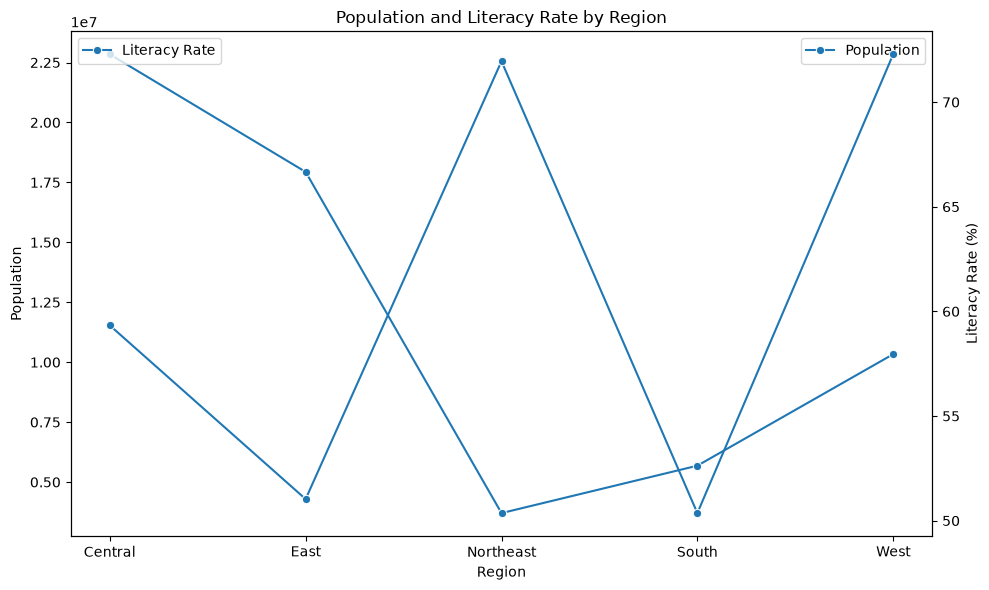

In [245]:
# Remove the overall tribal total because we are comparing individual tribes
viz_df = analysis_df[
    analysis_df["Tribe"] != "All Schedule Tribes"
].copy()
# groupby() groups the data by Region
# agg() calculates the total Population and average Literacy Rate for each region
regional_data = viz_df.groupby("Region").agg(
    Population=("Population", "sum"),
    Literacy_Rate=("Literacy_Rate", "mean")
).reset_index()
# subplots() creates the figure and the first axis
fig, ax1 = plt.subplots(figsize=(10, 6))
# lineplot() creates the Population line
sns.lineplot(
    data=regional_data,
    x="Region",
    y="Population",
    marker="o",
    ax=ax1,
    label="Population"
)
# Set the labels and title for the first axis
ax1.set_xlabel("Region")
ax1.set_ylabel("Population")
ax1.set_title("Population and Literacy Rate by Region")
# twinx() creates a second y-axis because Population and Literacy Rate have different scales
ax2 = ax1.twinx()
# lineplot() creates the Literacy Rate line on the second axis
sns.lineplot(
    data=regional_data,
    x="Region",
    y="Literacy_Rate",
    marker="o",
    ax=ax2,
    label="Literacy Rate"
)
# Set the label for the second y-axis
ax2.set_ylabel("Literacy Rate (%)")
# tight_layout() adjusts the spacing so labels and titles fit properly
plt.tight_layout()
# show() displays the graph
plt.show()

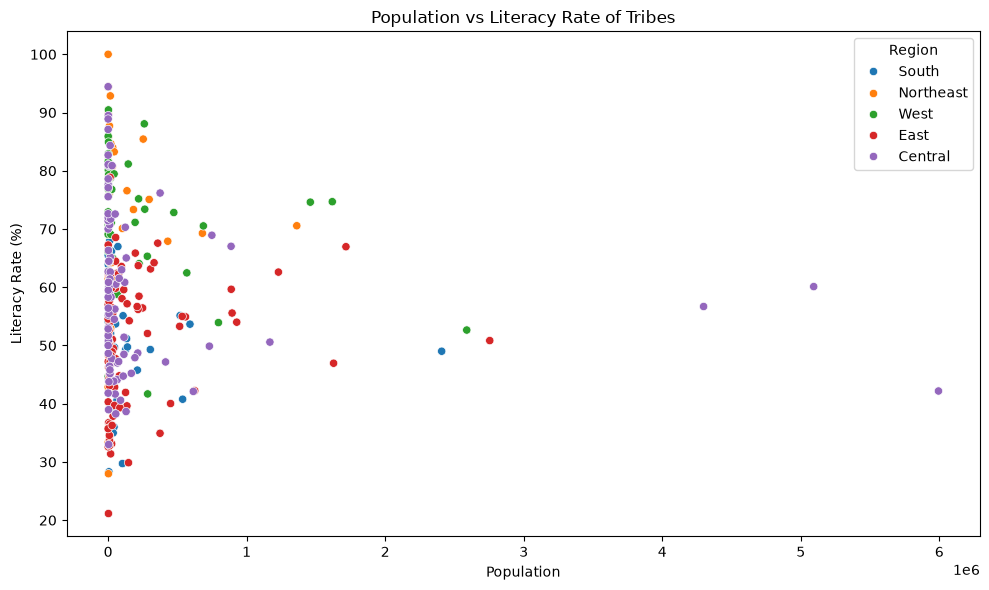

In [246]:
# figure() creates the plotting area and figsize sets its width and height
plt.figure(figsize=(10, 6))
# scatterplot() creates a scatter plot using Population and Literacy Rate
# hue="Region" gives different groups for each region
sns.scatterplot(
    data=viz_df,
    x="Population",
    y="Literacy_Rate",
    hue="Region"
)
# title() adds the title of the graph
plt.title("Population vs Literacy Rate of Tribes")
# xlabel() and ylabel() add labels to the axes
plt.xlabel("Population")
plt.ylabel("Literacy Rate (%)")
# legend() displays the region names
plt.legend(title="Region")
# tight_layout() adjusts the spacing of the graph
plt.tight_layout()
# show() displays the final graph
plt.show()

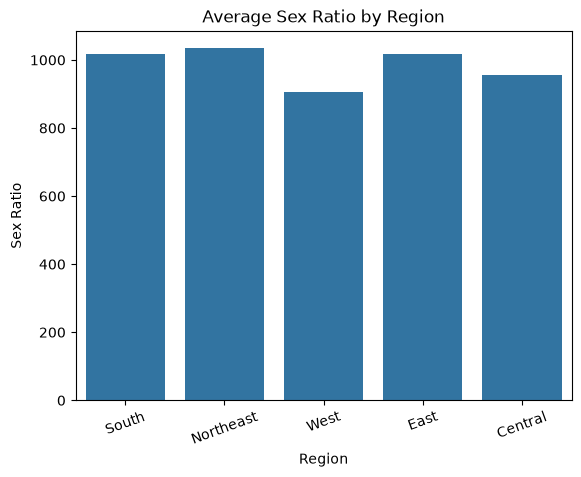

In [247]:
# barplot() compares the average Sex Ratio across the different regions
# estimator="mean" calculates the average value for each region
# errorbar=None removes the error bars from the plot
sns.barplot(
    data=viz_df,
    x="Region",
    y="Sex_Ratio",
    estimator="mean",
    errorbar=None
)
# Add the title and axis labels
plt.title("Average Sex Ratio by Region")
plt.xlabel("Region")
plt.ylabel("Sex Ratio")
# Rotate region names slightly for better readability
plt.xticks(rotation=20)
# Display the plot
plt.show()

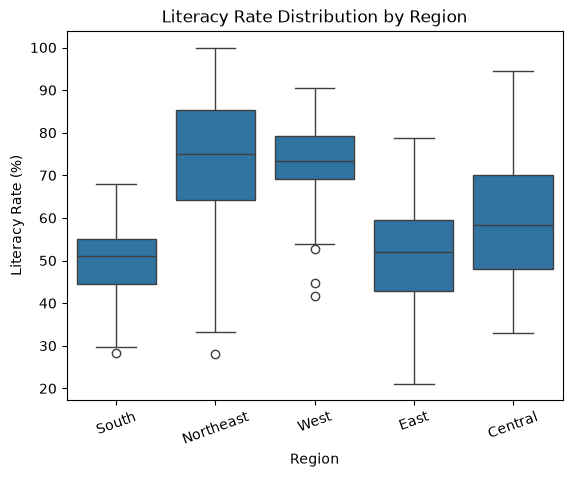

In [248]:
# boxplot() shows the distribution of Literacy Rate for each region
sns.boxplot(
    data=viz_df,
    x="Region",
    y="Literacy_Rate"
)
# Add the title and axis labels
plt.title("Literacy Rate Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Literacy Rate (%)")
# Rotate region names slightly for better readability
plt.xticks(rotation=20)
# Display the plot
plt.show()

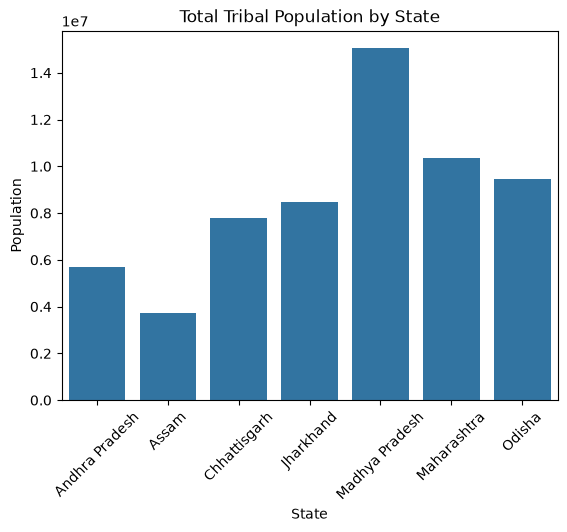

In [249]:
# groupby() groups the data by State
# sum() adds the population values within each state
# reset_index() converts the grouped result back into a DataFrame
state_population = (
    viz_df.groupby("State")["Population"]
    .sum()
    .reset_index()
)
# barplot() compares the total population across states
# errorbar=None removes the error bars
sns.barplot(
    data=state_population,
    x="State",
    y="Population",
    errorbar=None
)
# Add the title and axis labels
plt.title("Total Tribal Population by State")
plt.xlabel("State")
plt.ylabel("Population")
# Rotate state names for better readability
plt.xticks(rotation=45)
# Display the plot
plt.show()

## Conclusion
The tribal population data was cleaned and analyzed using NumPy and Pandas, and demographic indicators such as Population, Literacy Rate, and Sex Ratio were calculated. The data was also grouped by Region and Tribe to understand the distribution of tribal records across the selected states. Seaborn and Matplotlib visualizations helped compare population, literacy rate, and sex ratio across regions and states.
During data preparation, missing values and duplicate records were checked and handled where required. Some derived indicators also needed validation to ensure that the calculated values were within reasonable ranges. Overall, the analysis provided a basic understanding of demographic and socio-economic patterns in the selected tribal population data.